<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Imports" data-toc-modified-id="Imports-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Imports</a></span></li><li><span><a href="#Paternity-Assignment" data-toc-modified-id="Paternity-Assignment-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Paternity Assignment</a></span></li><li><span><a href="#Generating-Consensus-Sequences" data-toc-modified-id="Generating-Consensus-Sequences-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Generating Consensus Sequences</a></span><ul class="toc-item"><li><span><a href="#Global-Variables" data-toc-modified-id="Global-Variables-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Global Variables</a></span></li><li><span><a href="#Generating-Cluster-Specific-FASTA-Files" data-toc-modified-id="Generating-Cluster-Specific-FASTA-Files-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Generating Cluster Specific FASTA Files</a></span></li><li><span><a href="#Generating-Multiple-Sequence-Alignments" data-toc-modified-id="Generating-Multiple-Sequence-Alignments-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Generating Multiple Sequence Alignments</a></span></li><li><span><a href="#Extracting-Consensus-Sequences" data-toc-modified-id="Extracting-Consensus-Sequences-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Extracting Consensus Sequences</a></span></li></ul></li><li><span><a href="#Comparing-Consensus-Sequences" data-toc-modified-id="Comparing-Consensus-Sequences-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Comparing Consensus Sequences</a></span><ul class="toc-item"><li><span><a href="#Global-Variables" data-toc-modified-id="Global-Variables-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Global Variables</a></span></li><li><span><a href="#Pairwise-Alignment" data-toc-modified-id="Pairwise-Alignment-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Pairwise Alignment</a></span></li><li><span><a href="#Filtering-Alignment-and-Statistics" data-toc-modified-id="Filtering-Alignment-and-Statistics-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Filtering Alignment and Statistics</a></span></li><li><span><a href="#Generating-Combined-Stats" data-toc-modified-id="Generating-Combined-Stats-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Generating Combined Stats</a></span></li><li><span><a href="#Generate-Plots" data-toc-modified-id="Generate-Plots-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>Generate Plots</a></span><ul class="toc-item"><li><span><a href="#R" data-toc-modified-id="R-4.5.1"><span class="toc-item-num">4.5.1&nbsp;&nbsp;</span>R</a></span></li></ul></li></ul></li></ul></div>

# Imports

In [96]:
import os
import pysam
from Bio import SeqIO, pairwise2
import cairo
import IPython.display
import glob
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns

# Paternity Assignment

This notebook is designed to be used and executed to assign clusters of telomeric reads in an offspring sample to the two parents of origin. Clustering information can be found in the TARPON pipeline documentation. Briefly, the regions of telomeric sequence used in clustering (default 1,000 bp pre-telomore and 2,000 bp of the telomere) for each cluster are aligned in a multiple sequence alignment. Please note if you are doing this manually or modifying this code, the length of sequences going into the MSA for each individual must be identicial or the pident calculation will be skewed based on length differences instead of sequence identity.From this MSA, a consensus sequence per cluster is generated. The offsprings consensus sequences are aligned to the consensus sequence of both parents and percent identifies are determined. If the percent identity is greater than 85% and there is more than a 1% difference in identity between the best match of the two parents, paternity is assigned. Please note the alignment steps take a considerable amount of time and could be run directly from the command line as a python script by copying and pasting. Certain functions within this notebook generate bash scripts that must be run from the command line. In these cases, this is listed in the doc string as well as the program prerequisites.

# Generating Consensus Sequences

This portion of the notebook will need to be run three times for the individuals in question, the offspring and both parents

## Global Variables

In [2]:
TARPON_output_bam = "/media/data_01/ndeimler/DKC_PROJECT/DKC5/145_DKC5_QIAGEN/145_0.7.0_TARPON/sample/sample.telomeric.bam"
TARPON_output_stats = "/media/data_01/ndeimler/DKC_PROJECT/DKC5/145_DKC5_QIAGEN/145_0.7.0_TARPON/sample/sample.telo_stats.txt"
TARPON_output_clustering_file = "/media/data_01/ndeimler/DKC_PROJECT/DKC5/145_DKC5_QIAGEN/145_0.7.0_TARPON/sample/telogator_1000.2000/tlens_by_allele.tsv"
paternity_output_directory = "/media/data_01/ndeimler/paternity_test/"

In [6]:
if os.path.isdir(paternity_output_directory):
    print("Output Directory Exists - Running Further Scripts will Result in Data Overwritting")
    pass
else:
    print("Output Directory Created")
    os.mkdir(paternity_output_directory)

Output Directory Exists - Running Further Scripts will Result in Data Overwritting


## Generating Cluster Specific FASTA Files

In [18]:
def get_sequence_dict(bam_file):
    """creates a dictionary from a bam file where keys are read ids and values are sequence"""
    
    seq_dict = {}
    aln_file = pysam.AlignmentFile(bam_file, "rb", check_sq=False)
    for aln in aln_file:
        seq_dict[aln.query_name] = aln.query_sequence
    return seq_dict

def get_stats_dict(stats_file):
    """creates a dictionary from TARPON output where keys are reads ids and values are telomere start posiiton"""
    
    stats_dict = {}
    with open(stats_file, "r") as stats_fh:
        linecount = 0
        for line in stats_fh:
            if linecount == 0:
                linecount += 1
                continue
            line = line.strip().split()
            stats_dict[line[0]] = int(line[3])
    return stats_dict

def get_cluster_dict(cluster_file):
    """creates a dictionary from TARPON output where keys are cluster numbers and values are a list of assigned reads"""

    cluster_dict = {}
    with open(cluster_file, "r") as cluster_fh:
        linecount = 0
        for line in cluster_fh:
            if linecount == 0:
                linecount += 1
                continue
            line = line.strip().split()
            cluster_dict[int(line[3])] = [name.strip("@") for name in line[-1].split(",")]
    return cluster_dict
    
def generate_cluster_specific_fasta_files(bam_file, stats_file, cluster_file, out_dir):
    
    cluster_dict = get_cluster_dict(cluster_file)
    stats_dict = get_stats_dict(stats_file)
    seq_dict = get_sequence_dict(bam_file)
    
    if os.path.isdir("{}/FASTA_DIR".format(out_dir)):
        pass
    else:
        os.mkdir("{}/FASTA_DIR/".format(out_dir))
    
    for cluster in cluster_dict:
        with open("{}/FASTA_DIR/{}.fa".format(out_dir, cluster), "w") as cluster_fh:
            for read in cluster_dict[cluster]:
                if stats_dict[read]-1000 < 0:
                    cluster_fh.write(">{}\n{}\n".format(read, seq_dict[read][0:stats_dict[read]+2000]))
                else:
                    cluster_fh.write(">{}\n{}\n".format(read, seq_dict[read][stats_dict[read]-1000:stats_dict[read]+2000]))

In [33]:
generate_cluster_specific_fasta_files(TARPON_output_bam, TARPON_output_stats, TARPON_output_clustering_file, paternity_output_directory)

[E::idx_find_and_load] Could not retrieve index file for '/media/data_01/ndeimler/DKC_PROJECT/DKC5/145_DKC5_QIAGEN/145_0.7.0_TARPON/sample/sample.telomeric.bam'


## Generating Multiple Sequence Alignments

In [27]:
def generate_msa_file(out_dir):
    """this function generates a bash script to perform multiple sequence alignment based 
    on the cluster fasta files generated above. The bash script generated will need to be made executable.
    If using a system with slurm installed, the code can simply be copied and pasted into the slurm script.
    SPOA version 4.1.4 needs to be installed. I used a basic conda environment."""
    
    if os.path.isdir("{}/MSA".format(out_dir)):
        pass
    else:
        os.mkdir("{}/MSA/".format(out_dir))
        
    with open("{}/MSA/spoa.sh".format(out_dir), "w") as msa_file:
        msa_file.write("for file in $(ls -1 {}/FASTA_DIR/*.fa)\n".format(out_dir))
        msa_file.write("do\n")
        msa_file.write("\tout_prefix=$(basename ${file} | cut -f 1 -d '.')\n")
        msa_file.write("\t/usr/bin/time -v spoa -r 2 -l 1 $file > {}/MSA/$out_prefix.spoa.out\n".format(out_dir))
        msa_file.write("done")
        

In [28]:
generate_msa_file(paternity_output_directory)

In [54]:
def visualize_alignment_result(aln_file, out_dir):
    
    image_width=1500
    image_height=1000
    seq_dict = {}
    consensus = ""
    
    seq_dict = SeqIO.to_dict(SeqIO.parse(aln_file, "fasta"))
    consensus = seq_dict["Consensus"].seq
    seq_dict.pop("Consensus")
    # generate cairo image
    max_len = len(consensus)

    sequences = [seq_dict[seq].seq for seq in seq_dict]
    #height must be number of records *1.52

    surface = cairo.ImageSurface(cairo.FORMAT_RGB24,
                                 image_width,
                                 image_height)
    ctx = cairo.Context(surface)
    ctx.rectangle(0, 0, image_width, image_height)
    ctx.set_source_rgb(1,1,1)
    ctx.fill()
    x_offset_left=150
    x_offset_right=50
    y_offset_top=150
    y_offset_bottom=50
    
    ctx.set_source_rgb(0,0,0)
    ctx.rectangle(x_offset_left - 3, y_offset_top, 3, image_height-y_offset_bottom-y_offset_top + 3)
    ctx.rectangle(x_offset_left, image_height-y_offset_bottom, image_width-x_offset_left - x_offset_right, 3)
    ctx.fill()
#     ctx.set_source_rgb(0,0,1)
#     ctx.rectangle(x_offset_left, y_offset_top, image_width-x_offset_left - x_offset_right, image_height-y_offset_bottom-y_offset_bottom)
#     ctx.fill()
    sequence_height = (image_height-y_offset_bottom-y_offset_top) / len(sequences)
    nucl_width = (image_width - x_offset_left - x_offset_right) / max_len
    
    ctx.set_font_size(20)
    ctx.select_font_face("Courier",
                          cairo.FONT_SLANT_NORMAL,
                          cairo.FONT_WEIGHT_NORMAL)

#     # Drawing code
    ctx.set_source_rgb(0, 0, 0)
    for i in range(0, max_len-1000, 1000):
        if i % 2000 == 0:
            a,b,width,height,c,d = ctx.text_extents('{}'.format(i))
            ctx.move_to(x_offset_left + i*nucl_width - width/2 + 1000*nucl_width - 2.5, image_height - y_offset_bottom + 25)
            ctx.text_path('{}'.format(i))
            ctx.fill()
        ctx.rectangle(x_offset_left + i*nucl_width - 2.5, image_height-y_offset_bottom, 5, 5)
        ctx.fill()
    
    for i in range(0, len(sequences), 10):
        if i % 10 == 0:
            a,b,width,height,c,d = ctx.text_extents('{}'.format(i))
            ctx.move_to(x_offset_left - width - 10, image_height - y_offset_bottom - i*sequence_height + height/2)
            ctx.text_path('{}'.format(i))
        ctx.rectangle(x_offset_left-5, image_height - y_offset_bottom - i*sequence_height - 2.5, 5, 5)
        ctx.fill()
    
    a,b,width,height,c,d = ctx.text_extents('Consensus'.format(i))
    ctx.move_to(x_offset_left - width - 10, y_offset_top/2)
    ctx.text_path("Consensus")
    ctx.fill()
    
    #for loop goes here
    x_rect = x_offset_left
    y_rect = y_offset_top
    height=200
    for read in sequences:
        i = 0
        while i < len(read):
            if read[i:i+6] == 'GGTTAG':
                i += 6
                #print('GGTTAG')
                ctx.set_source_rgb(0,0,1)
                ctx.rectangle(x_rect, y_rect, 6*nucl_width, sequence_height)
                ctx.fill()
                x_rect += 6*nucl_width
            elif read[i] == "-":
                ctx.set_source_rgb(1,0,0)
                ctx.rectangle(x_rect, y_rect, 1*nucl_width, sequence_height)
                ctx.fill()
                x_rect += 1*nucl_width
                i+=1
            else:
                ctx.set_source_rgb(0,0,0)
                ctx.rectangle(x_rect, y_rect, 1*nucl_width, sequence_height)
                ctx.fill()
                x_rect += 1*nucl_width
                i+=1
        else:
            pass
        y_rect += sequence_height
        x_rect = x_offset_left
        
    # plot consensus
    i = 0
    x_rect = x_offset_left
    y_rect = y_offset_top/2 - sequence_height * 2
    sequence_height *= 3
    while i < len(consensus):
        if consensus[i:i+6] == 'GGTTAG':
            i += 6
            #print('GGTTAG')
            ctx.set_source_rgb(0,0,1)
            ctx.rectangle(x_rect, y_rect, 6*nucl_width, sequence_height)
            ctx.fill()
            x_rect += 6*nucl_width
        elif consensus[i] == "-":
            ctx.set_source_rgb(1,0,0)
            ctx.rectangle(x_rect, y_rect, 1*nucl_width, sequence_height)
            ctx.fill()
            x_rect += 1*nucl_width
            i+=1
        else:
            ctx.set_source_rgb(0,0,0)
            ctx.rectangle(x_rect, y_rect, 1*nucl_width, sequence_height)
            ctx.fill()
            x_rect += 1*nucl_width
            i+=1
    # End of drawing code
    
    surface.write_to_png("{}/MSA/{}.visualization.png".format(out_dir, aln_file.split("/")[-1].split(".")[0]))

def visualize_alignment_results(out_dir):
    
    for file in glob.iglob("{}/MSA/*.spoa.out".format(out_dir)):
        print(file)
        visualize_alignment_result(file, out_dir)
        

In [55]:
visualize_alignment_results(paternity_output_directory)

/media/data_01/ndeimler/paternity_test//MSA/18.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/17.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/40.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/0.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/120.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/50.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/37.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/38.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/60.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/86.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/110.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/89.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/28.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/27.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/70.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/100.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/8.spoa.out
/media/data_01/ndeimler/paternity_test//MSA/7.s

IPython.display.Image("/media/data_01/ndeimler/paternity_test/MSA/0.visualization.png")

## Extracting Consensus Sequences

In [64]:
def extract_consensus_seqs(out_dir):
    
    consensus_dict = {}
    for file in glob.iglob("{}/MSA/*.spoa.out".format(out_dir)):
        cluster = file.split("/")[-1].split(".")[0]
        seq_dict = SeqIO.to_dict(SeqIO.parse(file, "fasta"))
        consensus_dict[cluster] = seq_dict["Consensus"].seq.replace("-", "")

    with open("{}/MSA/consensus_seqs.fa".format(out_dir), "w") as con_fa:
        for cluster in consensus_dict:
            con_fa.write(">{}\n{}\n".format(cluster, consensus_dict[cluster]))


In [65]:
extract_consensus_seqs(paternity_output_directory)

# Comparing Consensus Sequences

## Global Variables

In [3]:
offspring_alignment_directory = "/media/data_01/ndeimler/paternity_test/offspring/"
mother_alignment_directory = "/media/data_01/ndeimler/paternity_test/mother/"
father_alignment_directory = "/media/data_01/ndeimler/paternity_test/father/"
output_directory = "/media/data_01/ndeimler/paternity_test/"

## Pairwise Alignment

In [127]:
def align_samples(fasta_A, fasta_B, comparison, out_dir):
    """ this function actually performs the pairwise alignment between two individuals and is called by parental_similarity"""
    
    a_seqs = list(SeqIO.parse(fasta_A, "fasta"))
    b_seqs = list(SeqIO.parse(fasta_B, "fasta"))
    
    if os.path.isdir("{}/PATERNITY_ASSIGNMENT/".format(out_dir)):
        pass
    else:
        os.mkdir("{}/PATERNITY_ASSIGNMENT/".format(out_dir))
        
    with open("{}/PATERNITY_ASSIGNMENT/{}.txt".format(out_dir, comparison), "w") as fh:
        fh.write("Offspring\t{}\tPerc_ID\n".format(comparison))
        for a_seq in a_seqs:
            for b_seq in b_seqs:
                aln = pairwise2.align.globalxx(a_seq.seq, b_seq.seq, one_alignment_only=True)[0]
                matches = aln[2]
                length = max(len(a_seq.seq), len(b_seq.seq))
                percent_id = (matches / length) * 100
                fh.write("{}\t{}\t{}\n".format(a_seq.id, b_seq.id, f"{percent_id:.2f}"))

def parental_similarity(offspring_alignment_directory, mother_alignment_directory, father_alignment_directory, output_directory):
    """This is the ultimate function designed to take the consensus sequences from the three individuals in question
    and determine the similarity between all pairs of consensus sequences between the offspring
    and the two parents. This is probably not the quickest way of doing this, but it works.
    This script will take multiple hours to run in Humans and the entire code block can be copied and pasted 
    into a script executable from the command line if necessary ensuring the proper packages are imported:
    "from Bio import SeqIO, pairwise2"
    """
    
    offspring_fasta = "{}/MSA/consensus_seqs.fa".format(offspring_alignment_directory)
    mother_fasta = "{}/MSA/consensus_seqs.fa".format(mother_alignment_directory)
    father_fasta = "{}/MSA/consensus_seqs.fa".format(father_alignment_directory)
    
    align_samples(offspring_fasta, mother_fasta, "Mother", output_directory)
    align_samples(offspring_fasta, father_fasta, "Father", output_directory)

In [128]:
parental_similarity(offspring_alignment_directory, mother_alignment_directory, father_alignment_directory, output_directory)

## Filtering Alignment and Statistics

In [22]:
def load_aln_results(aln_file):
    tmp = {}
    with open(aln_file, "r") as maternal_aln:
        linecount = 0
        for line in maternal_aln:
            if linecount == 0:
                linecount += 1
                continue
            line = line.strip().split()
            if line[0] not in tmp:
                tmp[line[0]] = {}
            tmp[line[0]][line[1]] = float(line[2])
    return tmp

def identify_best_match(aln_dict):
    
    tmp={}
    for cluster in aln_dict:
        max_id = 0
        best_cluster = None
        for match_cluster in aln_dict[cluster]:
            if aln_dict[cluster][match_cluster] > max_id:
                max_id = aln_dict[cluster][match_cluster]
                best_cluster = match_cluster
        if best_cluster is not None and max_id > 85:
            tmp[cluster] = [best_cluster, max_id]
    
    return tmp
    
def filter_and_assign_paternity(output_directory):
    
    # load dictionaries
    maternal_dict = load_aln_results("{}/PATERNITY_ASSIGNMENT/Mother.txt".format(output_directory))
    paternal_dict = load_aln_results("{}/PATERNITY_ASSIGNMENT/Father.txt".format(output_directory))
            
    # identify best match
    maternal_dict = identify_best_match(maternal_dict)
    paternal_dict = identify_best_match(paternal_dict)
    
    # compare mother to father
    paternity_dict = {}
    for cluster in set(list(maternal_dict.keys()) + list(paternal_dict.keys())):
        if cluster in maternal_dict and cluster not in paternal_dict:
            paternity_dict[cluster] = "Mother"
        elif cluster not in maternal_dict and cluster in paternal_dict:
            paternity_dict[cluster] = "Father"
        elif cluster in maternal_dict and cluster in paternal_dict:
            if abs(maternal_dict[cluster][1] - paternal_dict[cluster][1]) <= 1:
                paternity_dict[cluster] = "Unassigned"
            elif maternal_dict[cluster][1] > paternal_dict[cluster][1]:
                paternity_dict[cluster] = "Mother"
            elif maternal_dict[cluster][1] < paternal_dict[cluster][1]:
                paternity_dict[cluster] = "Father"
            else:
                print("ERROR")
        else:
            paternity_dict[cluster] = "Unassigned"

    with open("{}/PATERNITY_ASSIGNMENT/paternity_assignment.txt".format(output_directory), "w") as out_fh:
        for cluster in paternity_dict:
            out_fh.write("{}\t{}\n".format(cluster, paternity_dict[cluster]))
    print(Counter(paternity_dict.values()))


In [23]:
filter_and_assign_paternity(output_directory)

Counter({'Father': 43, 'Mother': 41, 'Unassigned': 5})


## Generating Combined Stats


In [30]:
output_directory = "/media/data_01/ndeimler/paternity_test/"
TARPON_offspring_clustering_file = "/media/data_01/ndeimler/DKC_PROJECT/DKC10/146_DKC10_ROBOT/146_0.7.0_TARPON/sample/telogator_1000.2000/tlens_by_allele.tsv"
TARPON_offspring_stats_file = "/media/data_01/ndeimler/DKC_PROJECT/DKC10/146_DKC10_ROBOT/146_0.7.0_TARPON/sample/sample.telo_stats.txt"

In [ ]:
def get_paternity_dict(paternity_file):
    paternity_dict = {}
    with open(paternity_file, "r") as paternity_file:
        for line in paternity_file:
            line = line.strip().split()
            paternity_dict[line[0]] = line[1]
    return paternity_dict

def invert_cluster_dict(cluster_dict):
    inverted_dict={}
    for cluster in cluster_dict:
        for read in cluster_dict[cluster]:
            inverted_dict[read] = str(cluster)
    return inverted_dict

def get_telo_length(tarpon_file):
    
    stats_dict = {}
    with open(tarpon_file, "r") as stats:
        linecount = 0 
        for line in stats:
            if linecount == 0:
                linecount += 1
                continue
            line = line.strip().split()
            stats_dict[line[0]] = int(line[4])
    return stats_dict

In [84]:
def generate_combined_stats_file(output_directory, offspring_cluster_file, offspring_TARPON_stats):
    
    cluster_dict = invert_cluster_dict(get_cluster_dict(offspring_cluster_file))  
    paternity_dict = get_paternity_dict("{}/PATERNITY_ASSIGNMENT/paternity_assignment.txt".format(output_directory))
    telo_length_dict = get_telo_length(offspring_TARPON_stats)
  
    with open("{}/PATERNITY_ASSIGNMENT/offspring_paternity_stats.txt".format(output_directory), "w") as stats_fh:
        stats_fh.write("read_id\ttelo_length\tcluster\tpaternity\n")
        for read in telo_length_dict:
            if read not in cluster_dict:
                stats_fh.write("{}\t{}\tNot_Clustered\tUnassigned\n".format(read, telo_length_dict[read]))
            elif cluster_dict[read] not in paternity_dict:
                stats_fh.write("{}\t{}\tUnassigned\tUnassigned\n".format(read, telo_length_dict[read]))
            else:
                stats_fh.write("{}\t{}\t{}\t{}\n".format(read, telo_length_dict[read], cluster_dict[read], paternity_dict[cluster_dict[read]]))
   

In [85]:
 generate_combined_stats_file(output_directory, TARPON_offspring_clustering_file, TARPON_offspring_stats_file)

## Generate Plots
Plots can be generated the provided R script (plots.R) via ggplot2. The output file of generate_combined_stats_file ("{output_directory}/PATERNITY_ASSIGNMENT/offspring_paternity_stats.txt" where output_directory is your specified directory) must be provided in the output_stats variable. Aditional the figure_directory variable needs to be specified as the path you would like the figures to be generated in (figure_directory). The figure generation directory in the python below can be replaced with the directory specified in your R script.

### R
stringr, ggplot2, and dplyr must be installed in the execution environment

In [107]:
%%bash 
cat ./plots.R

library(ggplot2)
library(stringr)
library(dplyr)


figure_directory <- "/media/data_01/ndeimler/paternity_test/PATERNITY_ASSIGNMENT/"
output_stats <- "/media/data_01/ndeimler/paternity_test/PATERNITY_ASSIGNMENT/offspring_paternity_stats.txt"

final_df <- read.table(output_stats, header=TRUE, sep="\t")

##### Inheritance Patterns ####

final_df$cluster <- factor(final_df$cluster, level=final_df %>% distinct(cluster, paternity) %>% arrange(paternity, cluster) %>% pull(cluster))

order_df <- final_df %>% group_by(cluster, paternity) %>% summarise(mean_val=mean(telo_length), .groups="drop") %>%
	arrange(paternity, mean_val) %>% mutate(cluster=factor(cluster, levels=cluster))

final_df$cluster <- factor(final_df$cluster, levels=levels(order_df$cluster)) 

plt <- ggplot(data=final_df) +
  geom_boxplot(mapping=aes(x=cluster, y=telo_length, fill=paternity)) + 
  theme_minimal() + ylab("Telomere Length (bp)") +
  theme(axis.text=element_text(size=14),
        axis.title=element_text(size=18),
 

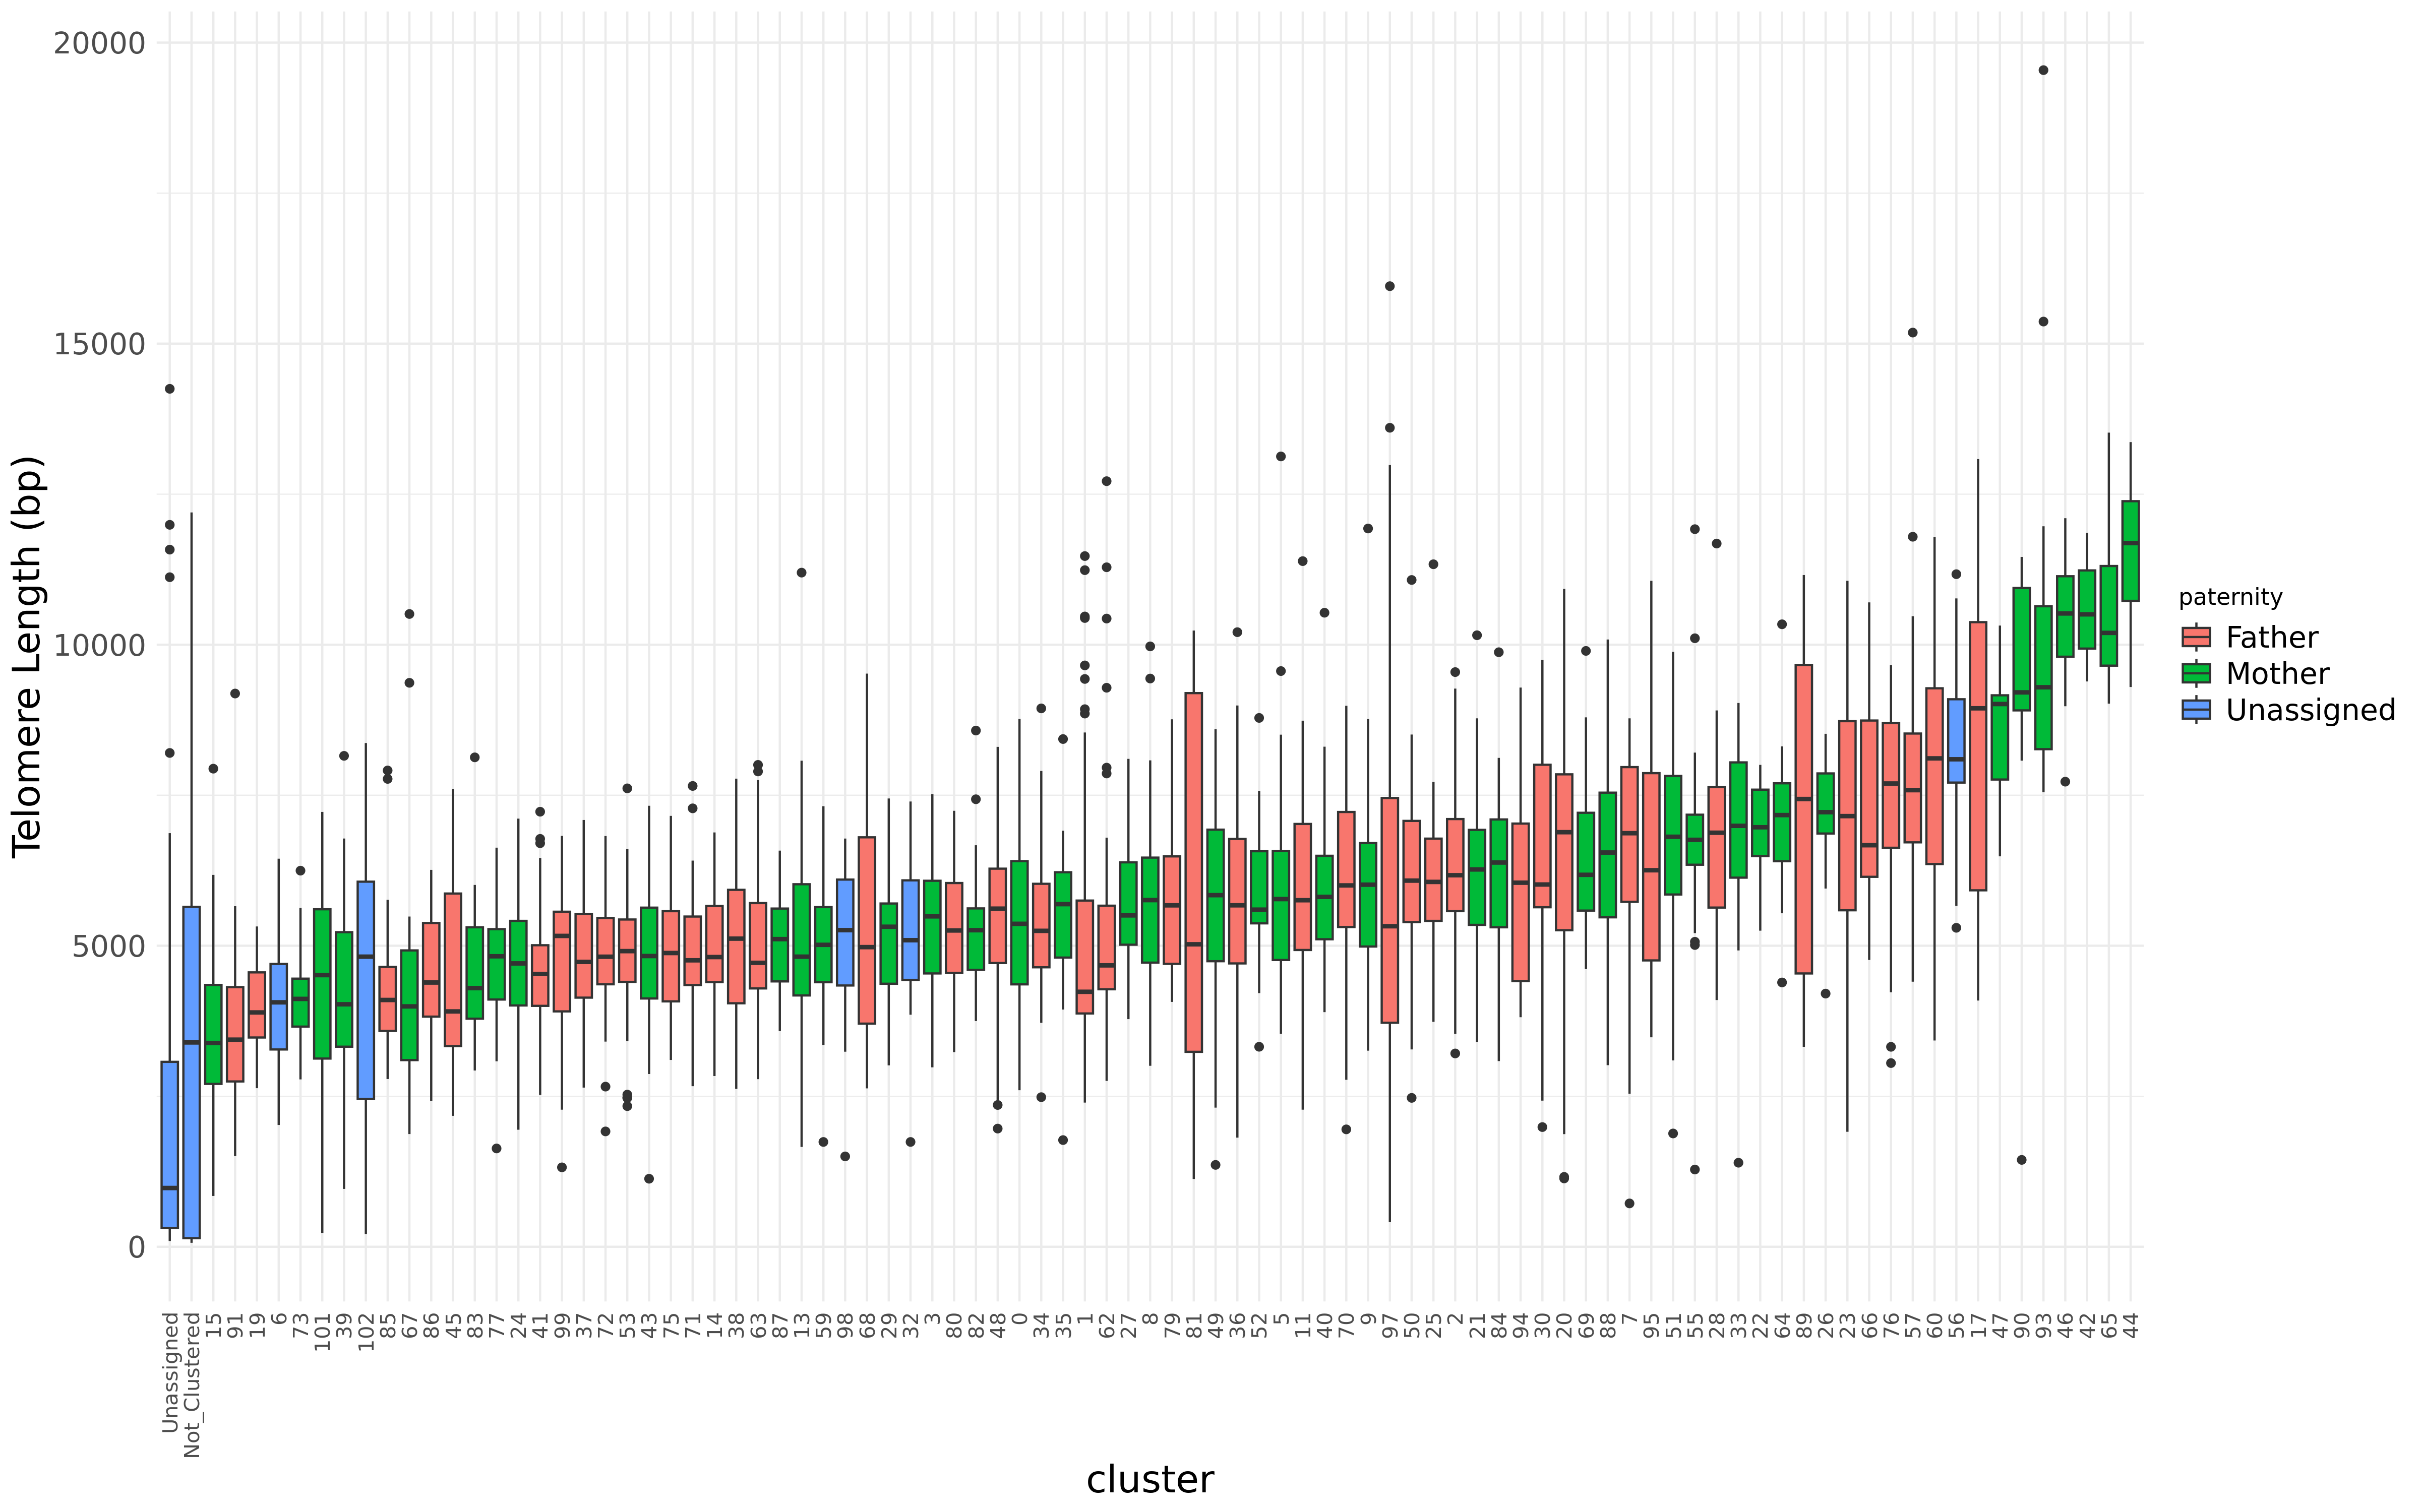

In [108]:
figure_generation = "/media/data_01/ndeimler/paternity_test/PATERNITY_ASSIGNMENT/"
IPython.display.Image("{}/telomere_length_by_cluster.png".format(figure_generation))

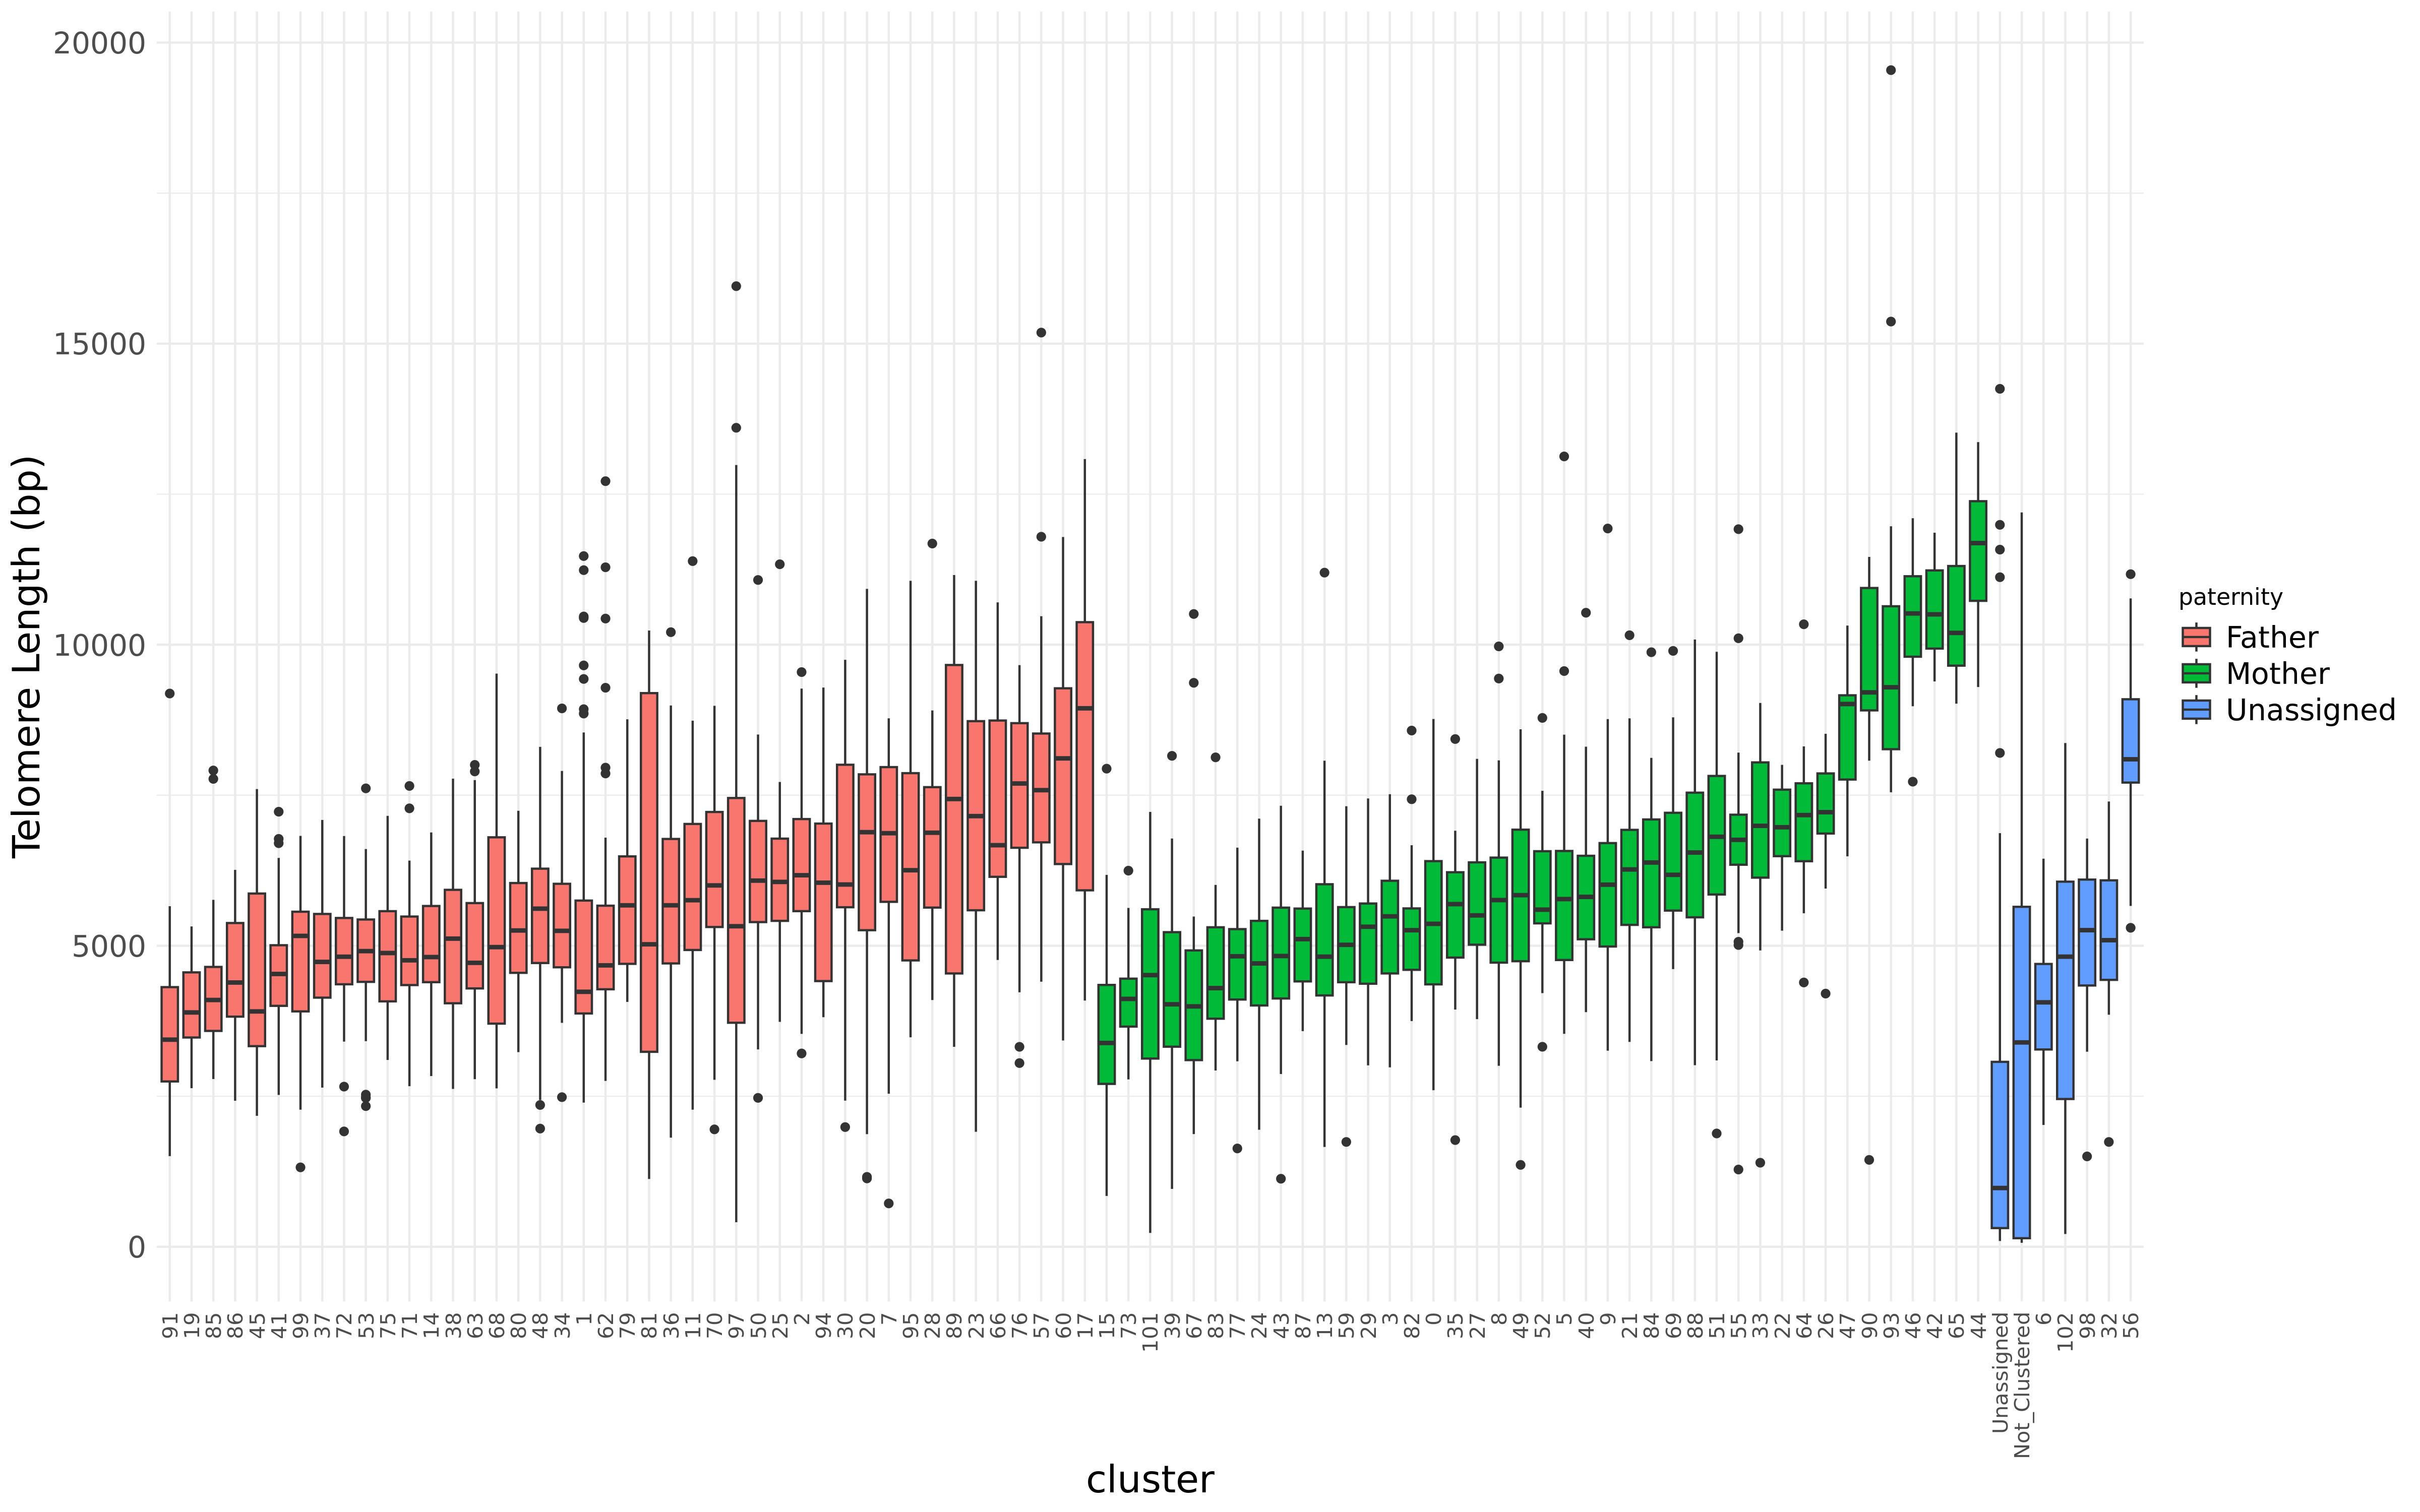

In [109]:
IPython.display.Image("{}/telomere_length_segregated.png".format(figure_generation))